In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from constants import *
from preprocessing import load_house_df

import warnings
warnings.filterwarnings("ignore")

set_project_theme()
pd.set_option("display.width", 120)
%matplotlib inline

In [10]:
house_df = load_house_df()
house_df.head()

,international,age,semesters_completed,commute_distance_km,financial_need_score,housing_urgency_rating,grades,should_recieve_housing,HO,A1,A2,A3,A4,grades_raw,grade_format,international_bin,age_group
0,domestic,26,2,31.1,62.93,5.8,46.488294,1,1,0,1,0,0,4.34,numeric_0_10,0,25 or older
1,domestic,27,5,13.2,66.45,5.9,61.705686,1,1,0,1,1,0,4.83,numeric_0_10,0,25 or older
2,domestic,25,5,9.8,50.23,5.2,50.063158,1,0,0,0,0,0,NaN,missing,0,25 or older
3,domestic,21,2,20.2,56.99,5.7,3.631151,1,1,0,0,1,0,2.06,numeric_0_10,0,under 25
4,domestic,34,7,51.9,32.31,4.6,43.430483,0,0,0,0,0,0,4.24,numeric_0_10,0,25 or older


# Section 4.3: Subgroup Fairness

Both functions above take a binary `G`, so they can only compare two groups at a time. For the subgroups we have
four cells (domestic under 25, domestic 25 or older, international under 25, international 25 or older), so we
generalise the same two metrics to a group column with any number of levels and report the largest gap between the
cells. A method is fair only if the largest gap stays inside the 5 point margin.

In [11]:
house_df['subgroup'] = (
    house_df.international.map({'international': 'international', 'domestic': 'domestic'}) + ', ' +
    (house_df.age < 25).map({True: 'under 25', False: '25 or older'})
)

house_df.subgroup.value_counts()

subgroup
domestic, 25 or older         1085
domestic, under 25             822
international, 25 or older     327
international, under 25        266
Name: count, dtype: int64

### Same two metrics as before, but across every level of group_column instead of two groups.
  **predictive_parity: P(T=1 | S=1, G=g)** => To keep it more readable, we just consider posetive predictive parity here. 

  **false_negatives:   P(S=0 | T=1, G=g)**

In [12]:
def calculate_subgroup_fairness(group_column, T, predictors, metric='predictive_parity', margin=MARGIN):
    levels = sorted(group_column.unique())
    subgroup_fairness = pd.DataFrame(index=predictors, columns=['fair', 'max gap'] + levels)

    for predictor in predictors:
        S = house_df[predictor]
        values = {}

        for level in levels:
            G = group_column == level

            if metric == 'predictive_parity':
                numerator, denominator = sum((G==1)*(T==1)*(S==1)), sum((S==1) * (G==1))
            else:
                numerator, denominator = sum((G==1)*(T==1)*(S==0)), sum((T==1) * (G==1))

            assert denominator > 0, f'empty denominator for {predictor} in {level}'
            values[level] = numerator / denominator

        gap = max(values.values()) - min(values.values())

        for level in levels:
            subgroup_fairness.loc[subgroup_fairness.index == predictor, [level]] = values[level]
        subgroup_fairness.loc[subgroup_fairness.index == predictor, ['max gap']] = gap
        subgroup_fairness.loc[subgroup_fairness.index == predictor, ['fair']] = (gap <= margin)

    return subgroup_fairness.astype(float).round(3)

In [13]:
sizes = pd.DataFrame({
    'n': house_df.subgroup.value_counts(),
    'n with T=1': house_df[house_df.should_recieve_housing == 1].subgroup.value_counts(),
})
sizes['share T=1'] = (sizes['n with T=1'] / sizes['n']).round(3)
sizes

,n,n with T=1,share T=1
subgroup,,,
"domestic, 25 or older",1085,240,0.221
"domestic, under 25",822,353,0.429
"international, 25 or older",327,110,0.336
"international, under 25",266,172,0.647


### Predictive parity across the four subgroups

In [14]:
T = house_df.should_recieve_housing

sg_pp = calculate_subgroup_fairness(house_df.subgroup, T, predictors, metric='predictive_parity')
sg_pp

,fair,max gap,"domestic, 25 or older","domestic, under 25","international, 25 or older","international, under 25"
HO,0.0,0.110,0.804,0.744,0.854,0.846
A1,0.0,0.186,0.667,0.825,0.661,0.847
A2,0.0,0.263,0.614,0.799,0.536,0.799
A3,0.0,0.272,0.766,0.833,0.672,0.943
A4,0.0,0.088,0.892,0.847,0.935,0.909


### Equality of false negatives across the four subgroups

In [15]:
sg_fn = calculate_subgroup_fairness(house_df.subgroup, T, predictors, metric='false_negatives')
sg_fn

,fair,max gap,"domestic, 25 or older","domestic, under 25","international, 25 or older","international, under 25"
HO,0.0,0.293,0.333,0.068,0.309,0.041
A1,0.0,0.314,0.550,0.465,0.236,0.291
A2,0.0,0.288,0.317,0.266,0.055,0.029
A3,0.0,0.200,0.412,0.263,0.218,0.419
A4,0.0,0.460,0.588,0.246,0.473,0.128


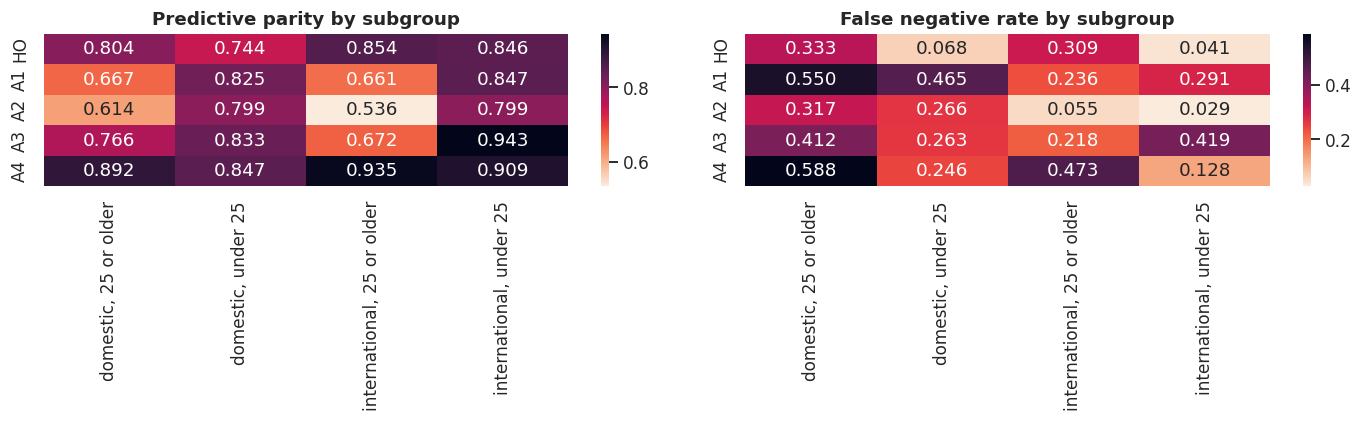

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

levels = sorted(house_df.subgroup.unique())
sns.heatmap(sg_pp[levels], annot=True, fmt='.3f', cmap=SEQUENTIAL_CMAP, ax=axes[0])
axes[0].set_title('Predictive parity by subgroup')

sns.heatmap(sg_fn[levels], annot=True, fmt='.3f', cmap=SEQUENTIAL_CMAP, ax=axes[1])
axes[1].set_title('False negative rate by subgroup')

plt.tight_layout()
plt.show()

In [17]:
pp_age = pd.read_csv(RESULTS_DIR / 'predictive_parity_age.csv', index_col=0)
pp_international = pd.read_csv(RESULTS_DIR / 'predictive_parity_international.csv', index_col=0)
fnr_age = pd.read_csv(RESULTS_DIR / 'false_negatives_age.csv', index_col=0)
fnr_international = pd.read_csv(RESULTS_DIR / 'false_negatives_international.csv', index_col=0)

In [18]:
comparison = pd.DataFrame({
    'PP gap age': pp_age['|a-b|'],
    'PP gap international': pp_international['|a-b|'],
    'PP gap subgroups': sg_pp['max gap'],
    'FN gap age': fnr_age['|a-b|'],
    'FN gap international': fnr_international['|a-b|'],
    'FN gap subgroups': sg_fn['max gap'],
})

comparison

,PP gap age,PP gap international,PP gap subgroups,FN gap age,FN gap international,FN gap subgroups
HO,0.044,0.086,0.110,0.267,0.030,0.293
A1,0.169,0.001,0.186,0.044,0.230,0.314
A2,0.218,0.043,0.263,0.046,0.248,0.288
A3,0.134,0.014,0.272,0.037,0.017,0.200
A4,0.039,0.057,0.088,0.344,0.122,0.460


### What we take from this section

**Every method fails subgroup fairness on both metrics.** The smallest gap in the whole table is A4 with 0.088 on
predictive parity, which is still nearly twice the margin. Not one of the five methods gets close.

**The bias that the single feature analysis hid is now visible.** A3 was the best method in section 4.2,
passing 3 of the 4 checks, and it has the largest predictive parity gap of all here, 0.271. Among the
international students under 25 that A3 selects, 94 percent really should receive housing, against 67 percent of
the selected international students of 25 or older. Looking at `international` alone gave 0.795 against 0.808, a
gap of 0.014, so the two international cells were cancelling each other out and the feature looked perfectly fair.
This is exactly the situation the assignment describes, where fairness per feature disguises the bias.

**The pattern is consistent across all methods.** Being over 25 is the main disadvantage, and being over 25 and
domestic is the worst cell for almost every method. For A4 the false negative rate goes from 0.128 for
international students under 25 up to 0.588 for domestic students of 25 or older, so an older domestic student who
should receive housing is refused more than four times as often as a younger international student in the same
situation.

**A caution about the numbers.** The international cells are small, 266 and 327 students, and after conditioning
they get smaller still. A4 selects only 62 international students of 25 or older, so its 0.935 rests on 62 people
and a handful of different decisions would move it noticeably. The domestic values are on firmer ground. The
conclusion that every method fails is safe because the gaps are far larger than the margin, but we should not read
too much into the exact ordering of the cells.

In [19]:
sg_pp.to_csv(RESULTS_DIR / 'subgroup_predictive_parity.csv')
sg_fn.to_csv(RESULTS_DIR / 'subgroup_false_negatives.csv')